In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
import plotly.express as px

In [69]:
df_career = pd.read_csv("career_path.csv")
df_student = pd.read_csv("stu_pref1.csv")

In [70]:
df_career

,Internships,Projects,Leadership_Positions,Communication_Skills,Problem_Solving_Skills,Teamwork_Skills,Analytical_Skills,Presentation_Skills,Networking_Skills,SVD1,SVD2,SVD3,Final_Cluster
0,0,2,0,4,2,2,1,0,1,1.480914,0.750548,0.808229,0
1,2,0,0,4,0,3,0,3,0,1.488576,0.746523,-0.563753,4
2,0,0,0,1,1,2,2,3,4,1.480948,0.749898,0.743916,0
3,1,3,0,1,3,1,2,1,2,1.476182,0.734913,-0.218897,2
4,2,4,0,4,3,4,4,3,2,1.485435,0.766852,-0.664286,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,1,3,0,1,2,3,3,3,4,1.486648,0.714442,-0.164522,2
8996,0,1,0,4,3,1,1,4,0,1.474202,0.749362,0.774677,0
8997,0,2,0,4,4,3,3,4,3,1.491353,0.734445,0.928447,0
8998,0,4,1,4,2,4,0,2,4,1.496266,-0.706209,0.753123,3


In [71]:
df_student

,traveltime,studytime,failures,schoolsup,famsup,paid,activities,internet,freetime,goout,Final_Cluster,C1,C2,C3
0,2,2,0,1,0,0,0,0,3,4,2,-1.045193,-1.415395,2.965835
1,1,2,0,0,1,0,0,1,3,3,1,0.621495,-0.304737,-0.081799
2,1,3,0,0,1,1,1,1,2,2,1,3.011772,-0.024797,-1.180737
3,1,2,0,0,1,1,0,0,3,2,2,1.399814,-1.559801,0.744232
4,1,2,0,0,1,1,1,1,4,2,1,1.522661,0.989807,-0.368822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734,2,2,0,0,0,0,0,1,5,4,0,-1.933537,0.775784,-0.040086
735,3,1,0,0,1,0,1,1,4,3,0,-1.499385,0.075538,-0.809468
736,1,2,0,0,1,0,0,1,3,4,1,0.363005,0.169693,-0.017142
737,2,1,0,0,0,0,0,1,4,5,0,-2.485063,0.566842,-0.083577


In [72]:
df_meta = pd.DataFrame({
    'Career Path' : df_career['Final_Cluster'],
    "Student Performance" : df_student['Final_Cluster']
})

In [73]:
df_meta

,Career Path,Student Performance
0,0,2.0
1,4,1.0
2,0,1.0
3,2,2.0
4,4,1.0
...,...,...
8995,2,NaN
8996,0,NaN
8997,0,NaN
8998,3,NaN


In [74]:
df_meta.shape

(9000, 2)

In [75]:
df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Career Path          9000 non-null   int64  
 1   Student Performance  739 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 140.8 KB


In [76]:
df_meta.isnull().sum()

Career Path               0
Student Performance    8261
dtype: int64

In [77]:
# Remove rows with missing values if any
df_meta = df_meta.dropna()
print(f"Meta-Dataframe created with {df_meta.shape[0]} students.")

Meta-Dataframe created with 739 students.


In [78]:
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(df_meta)

In [79]:
X_meta_scaled

array([[-1.44937388,  1.38431395],
       [ 0.8727666 ,  0.08111903],
       [-1.44937388,  0.08111903],
       ...,
       [-0.28830364,  0.08111903],
       [-0.28830364, -1.22207588],
       [-1.44937388,  1.38431395]], shape=(739, 2))

In [80]:
X_meta_scaled.shape

(739, 2)

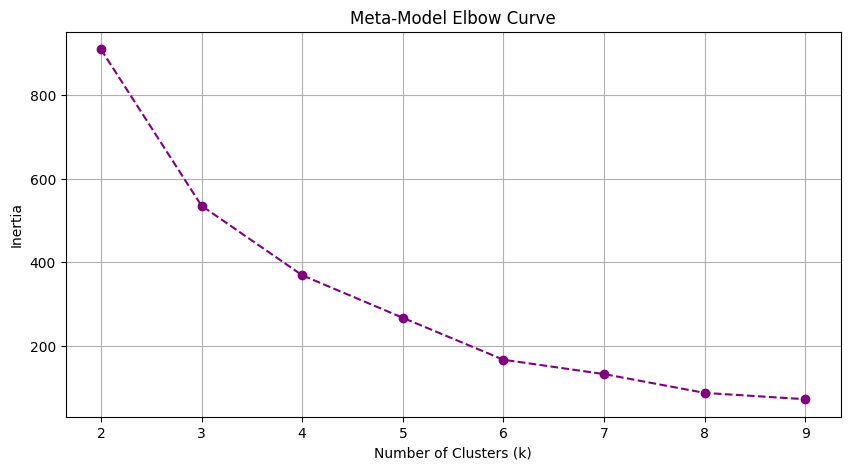

In [81]:
# Find optimal number of Meta-Clusters
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_meta_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', color='purple', linestyle='--')
plt.title('Meta-Model Elbow Curve')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [90]:
best_k = 6
meta_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_meta['Meta_cluster'] = meta_km.fit_predict(X_meta_scaled)

C:\Users\HIMPADMA\AppData\Local\Temp\ipykernel_4620\588642699.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [91]:
df_meta.head()

,Career Path,Student Performance,Meta_cluster
0,0,2.0,1
1,4,1.0,0
2,0,1.0,3
3,2,2.0,1
4,4,1.0,0


In [92]:
score = silhouette_score(X_meta_scaled, df_meta['Meta_cluster'])
print(f"Average Silhouette Score for Meta_Model: {score:.4f}")

Average Silhouette Score for Meta_Model: 0.6072


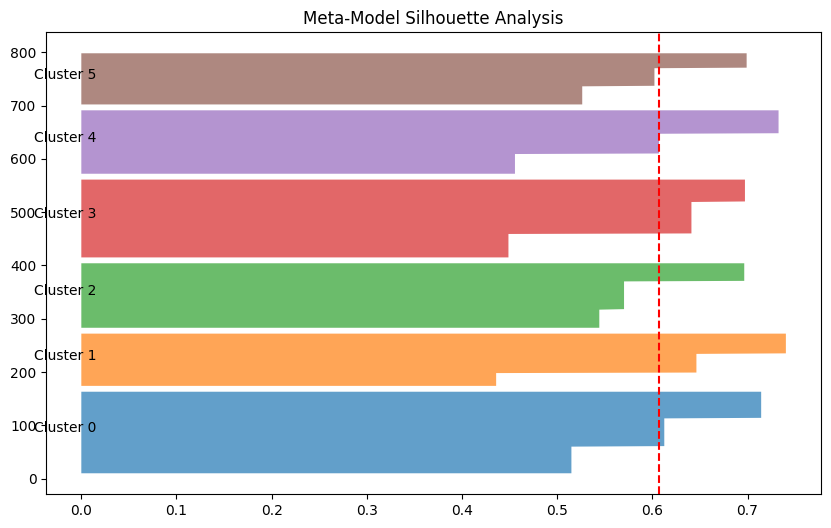

In [93]:
# Silhouette Plot Visualization
sample_values = silhouette_samples(X_meta_scaled, df_meta['Meta_cluster'])
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(best_k):
    ith_cluster_v = sample_values[df_meta['Meta_cluster'] == i]
    ith_cluster_v.sort()
    y_upper = y_lower + len(ith_cluster_v)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_v, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * len(ith_cluster_v), f'Cluster {i}')
    y_lower = y_upper + 10
plt.axvline(x=score, color='red', linestyle='--')
plt.title('Meta-Model Silhouette Analysis')
plt.show()

In [94]:
import plotly.express as px

# Prepare the data for Plotly
df_plot = df_meta.copy()
df_plot['Career Path'] = X_meta_scaled[:, 0]
df_plot['Student Performance'] = X_meta_scaled[:, 1]
df_plot['Meta_cluster'] = df_plot['Meta_cluster'].astype(str) # Convert to string for discrete color mapping

# Create 2D Plot
fig_2d = px.scatter(
    df_plot, 
    x='Career Path', 
    y='Student Performance', 
    color='Meta_cluster',
    hover_data=['Career Path', 'Student Performance'],
    title='Interactive 2D Meta-Cluster Visualization (SVD)',
    labels={'Career Path': 'Career Path', 'Student Performance': 'Student Performance'},
    template='plotly_dark'
)

fig_2d.show()

In [95]:
df_plot

,Career Path,Student Performance,Meta_cluster
0,-1.449374,1.384314,1
1,0.872767,0.081119,0
2,-1.449374,0.081119,3
3,-0.288304,1.384314,1
4,0.872767,0.081119,0
...,...,...,...
734,0.872767,-1.222076,4
735,1.453302,-1.222076,4
736,-0.288304,0.081119,3
737,-0.288304,-1.222076,2


In [96]:
import plotly.express as px

# Create 3D Plot
fig_3d = px.scatter_3d(
    df_plot, 
    x='Career Path', 
    y='Student Performance', 
    z='Meta_cluster',
    color='Meta_cluster',
    hover_data=['Career Path'],
    title='Interactive 3D Meta-Cluster Visualization',
    labels={'SVD1': 'SVD 1', 'SVD2': 'SVD 2', 'Student Performance': 'Performance Cluster'},
    template='plotly_dark',
    opacity=0.7
)

# Update layout to make it look cleaner
fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d.show()

,Career Path,Student Performance,Meta_cluster
0,0,2.0,2
1,4,1.0,0
2,0,1.0,1
3,2,2.0,2
4,4,1.0,0
...,...,...,...
734,4,0.0,4
735,5,0.0,4
736,2,1.0,1
737,2,0.0,3
